In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# data (as pandas dataframes)
X = pd.DataFrame(chronic_kidney_disease.data.features)
y = pd.DataFrame(chronic_kidney_disease.data.targets)

# metadata
print(chronic_kidney_disease.metadata)

# variable information
print(chronic_kidney_disease.variables)


{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

In [4]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   400 non-null    object
dtypes: object(1)
memory usage: 3.3+ KB


**Cleaning**

In [5]:
import pandas as pd
import numpy as np

# Check unique values in categorical columns
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nCOLUMN: {col}")
    print(X[col].unique())


COLUMN: rbc
[nan 'normal' 'abnormal']

COLUMN: pc
['normal' 'abnormal' nan]

COLUMN: pcc
['notpresent' 'present' nan]

COLUMN: ba
['notpresent' 'present' nan]

COLUMN: htn
['yes' 'no' nan]

COLUMN: dm
['yes' 'no' '\tno' nan]

COLUMN: cad
['no' 'yes' nan]

COLUMN: appet
['good' 'poor' nan]

COLUMN: pe
['no' 'yes' nan]

COLUMN: ane
['no' 'yes' nan]


In [6]:
# Clean whitespaces and tabs from categorical columns

for col in cat_cols:
    X[col] = X[col].astype(str).str.strip()

# Replace incorrect values
X['dm'] = X['dm'].replace({'\\tno': 'no'})

# Convert 'nan' strings back to actual NaN
X = X.replace('nan', np.nan)

# Check again
for col in cat_cols:
    print(f"\nCOLUMN: {col}")
    print(X[col].unique())


COLUMN: rbc
[nan 'normal' 'abnormal']

COLUMN: pc
['normal' 'abnormal' nan]

COLUMN: pcc
['notpresent' 'present' nan]

COLUMN: ba
['notpresent' 'present' nan]

COLUMN: htn
['yes' 'no' nan]

COLUMN: dm
['yes' 'no' nan]

COLUMN: cad
['no' 'yes' nan]

COLUMN: appet
['good' 'poor' nan]

COLUMN: pe
['no' 'yes' nan]

COLUMN: ane
['no' 'yes' nan]


In [7]:
print(y['class'].unique())
print(y['class'].value_counts())

['ckd' 'ckd\t' 'notckd']
class
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [8]:
# Clean target column

y['class'] = y['class'].astype(str).str.strip()

# Replace incorrect values
y['class'] = y['class'].replace({'ckd\t': 'ckd'})

# Check again
print(y['class'].unique())
print(y['class'].value_counts())

['ckd' 'notckd']
class
ckd       250
notckd    150
Name: count, dtype: int64


In [9]:
# Encode target

y['class'] = y['class'].map({
    'ckd': 1,
    'notckd': 0
})

print(y['class'].value_counts())

class
1    250
0    150
Name: count, dtype: int64


In [10]:
# Missing values percentage

missing = X.isnull().sum().sort_values(ascending=False)

missing_percent = (missing / len(X)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

print(missing_df)

       Missing Values  Percentage
rbc               152       38.00
rbcc              131       32.75
wbcc              106       26.50
pot                88       22.00
sod                87       21.75
pcv                71       17.75
pc                 65       16.25
hemo               52       13.00
su                 49       12.25
sg                 47       11.75
al                 46       11.50
bgr                44       11.00
bu                 19        4.75
sc                 17        4.25
bp                 12        3.00
age                 9        2.25
pcc                 4        1.00
ba                  4        1.00
htn                 2        0.50
dm                  2        0.50
cad                 2        0.50
appet               1        0.25
pe                  1        0.25
ane                 1        0.25


In [11]:
# Separate columns

num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include='object').columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wbcc', 'rbcc'],
      dtype='object')

Categorical Columns:
Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'], dtype='object')


In [12]:
from sklearn.impute import SimpleImputer

# Numerical imputation using median
num_imputer = SimpleImputer(strategy='median')

X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Categorical imputation using most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')

X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# Check missing values again
print(X.isnull().sum())

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
dtype: int64


In [13]:
from sklearn.preprocessing import LabelEncoder

# Store encoders if needed later
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Check dataset
print(X.head())

    age    bp     sg   al   su  rbc  pc  pcc  ba    bgr  ...  hemo   pcv  \
0  48.0  80.0  1.020  1.0  0.0    1   1    0   0  121.0  ...  15.4  44.0   
1   7.0  50.0  1.020  4.0  0.0    1   1    0   0  121.0  ...  11.3  38.0   
2  62.0  80.0  1.010  2.0  3.0    1   1    0   0  423.0  ...   9.6  31.0   
3  48.0  70.0  1.005  4.0  0.0    1   0    1   0  117.0  ...  11.2  32.0   
4  51.0  80.0  1.010  2.0  0.0    1   1    0   0  106.0  ...  11.6  35.0   

     wbcc  rbcc  htn  dm  cad  appet  pe  ane  
0  7800.0   5.2    1   1    0      0   0    0  
1  6000.0   4.8    0   0    0      0   0    0  
2  7500.0   4.8    0   1    0      1   0    1  
3  6700.0   3.9    1   0    0      1   1    1  
4  7300.0   4.6    0   0    0      0   0    0  

[5 rows x 24 columns]


In [14]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    float64
 1   bp      400 non-null    float64
 2   sg      400 non-null    float64
 3   al      400 non-null    float64
 4   su      400 non-null    float64
 5   rbc     400 non-null    int64  
 6   pc      400 non-null    int64  
 7   pcc     400 non-null    int64  
 8   ba      400 non-null    int64  
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    float64
 16  wbcc    400 non-null    float64
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    int64  
 19  dm      400 non-null    int64  
 20  cad     400 non-null    int64  
 21  appet   400 non-null    int64  
 22  pe

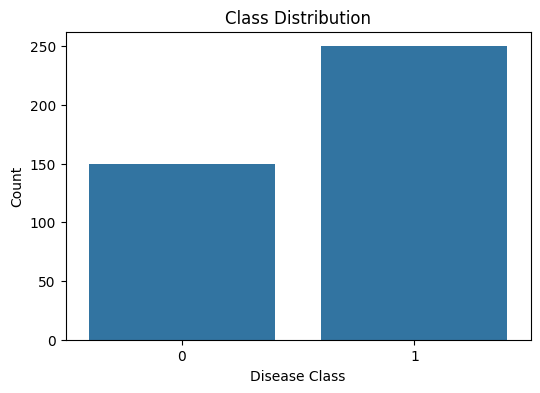

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=y['class'])

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Count")

plt.show()

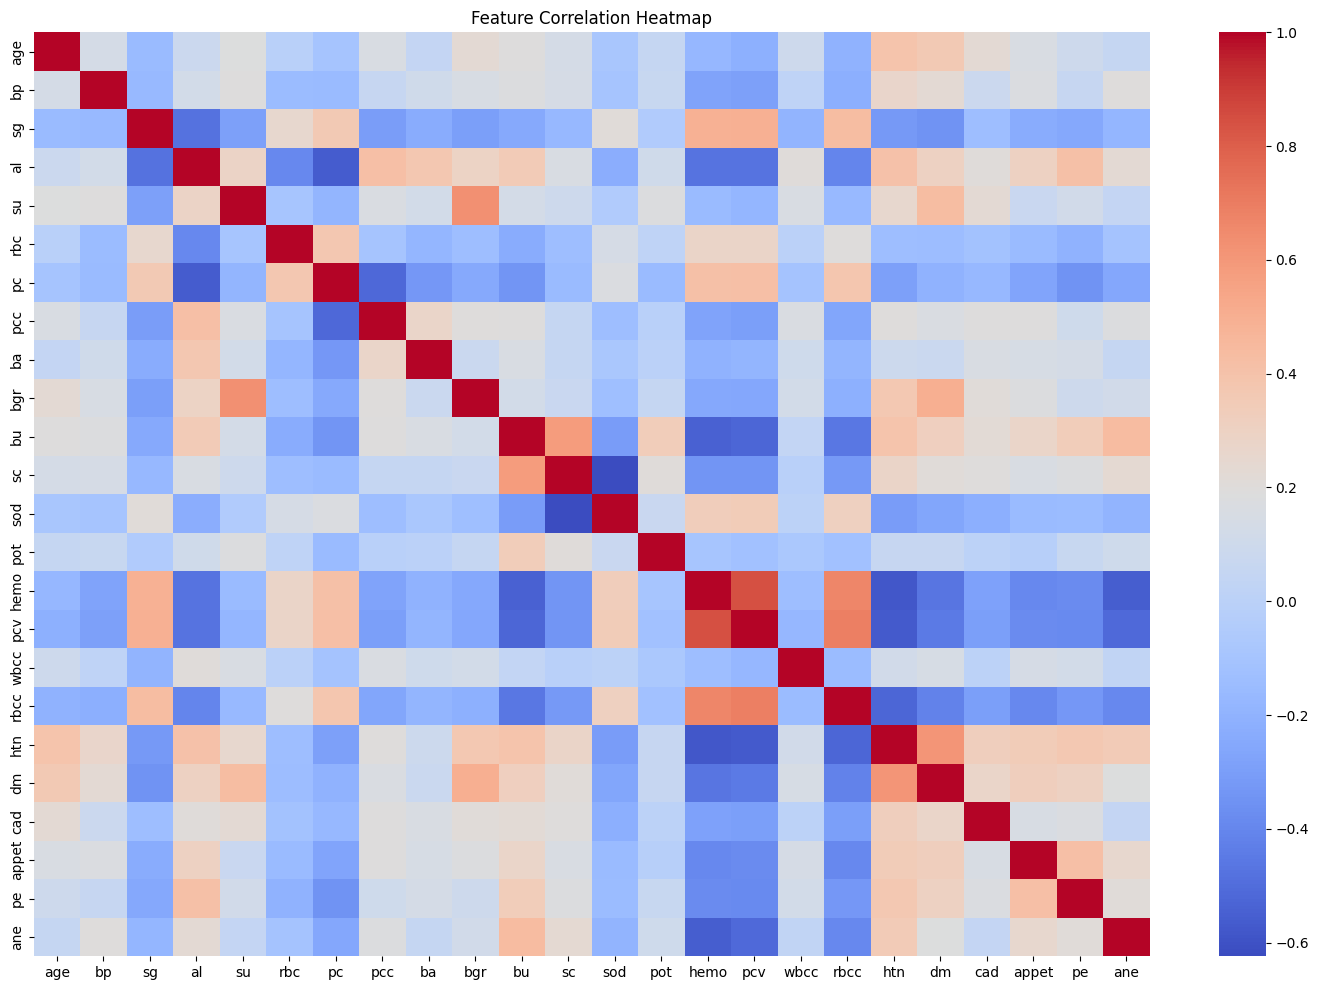

In [16]:
plt.figure(figsize=(18,12))

corr = X.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

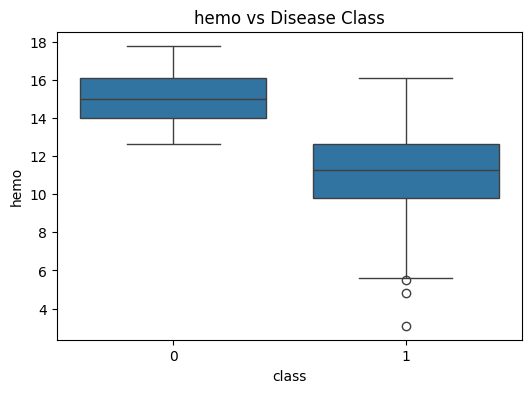

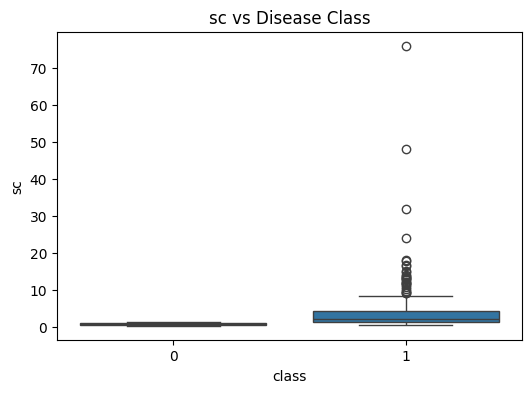

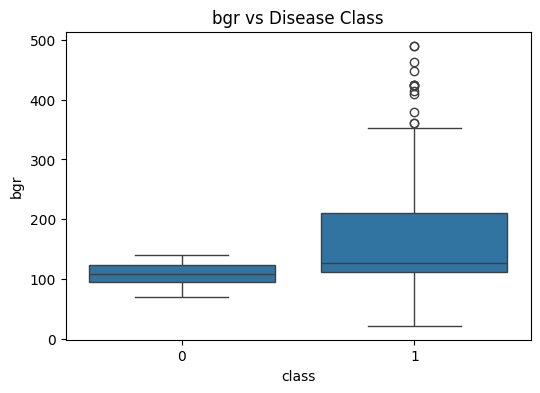

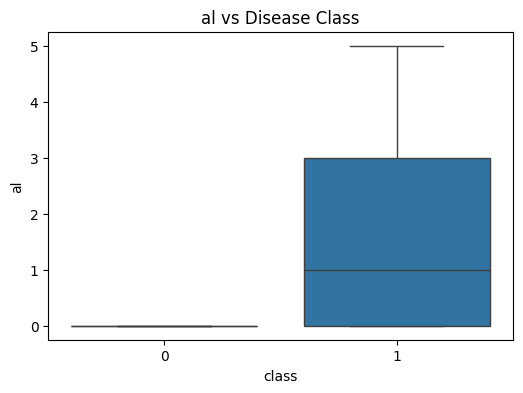

In [17]:
# Combine X and y temporarily

df = X.copy()
df['class'] = y['class']

important_features = ['hemo', 'sc', 'bgr', 'al']

for feature in important_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x='class', y=feature, data=df)

    plt.title(f"{feature} vs Disease Class")

    plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y['class'],
    test_size=0.2,
    random_state=42,
    stratify=y['class']
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (320, 24)
X_test shape: (80, 24)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
class
1    200
0    120
Name: count, dtype: int64

After SMOTE:
class
1    200
0    200
Name: count, dtype: int64


In [21]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train_smote,
    y_train_smote
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)

print(mi_df)

   Feature  MI Score
14    hemo  0.513586
15     pcv  0.490158
17    rbcc  0.432160
11      sc  0.405395
2       sg  0.390032
12     sod  0.295165
3       al  0.258840
18     htn  0.252638
19      dm  0.240489
1       bp  0.225654
13     pot  0.222812
10      bu  0.202445
9      bgr  0.183725
16    wbcc  0.181318
0      age  0.104259
22      pe  0.103451
6       pc  0.090500
23     ane  0.089896
21   appet  0.083415
7      pcc  0.064319
20     cad  0.063472
4       su  0.062388
5      rbc  0.048590
8       ba  0.020746


In [22]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Base model for RFE
lr = LogisticRegression(max_iter=1000)

# Select top 10 features
rfe = RFE(
    estimator=lr,
    n_features_to_select=10
)

rfe.fit(X_train_smote, y_train_smote)

# Selected features
selected_features = X.columns[rfe.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['sg', 'al', 'su', 'sc', 'hemo', 'pcv', 'rbcc', 'htn', 'dm', 'appet'], dtype='object')


In [23]:
# Convert scaled arrays to DataFrames temporarily

X_train_smote_df = pd.DataFrame(
    X_train_smote,
    columns=X.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

# Keep only selected features

X_train_final = X_train_smote_df[selected_features]

X_test_final = X_test_scaled_df[selected_features]

print(X_train_final.shape)
print(X_test_final.shape)

(400, 10)
(80, 10)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# Train model

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_final, y_train_smote)

# Predictions

lr_pred = lr_model.predict(X_test_final)

# Evaluation

print("Logistic Regression Results:\n")

print(classification_report(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

Logistic Regression Results:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

F1 Score: 0.98989898989899


In [25]:
from sklearn.ensemble import RandomForestClassifier

# Train model

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_final, y_train_smote)

# Predictions

rf_pred = rf_model.predict(X_test_final)

# Evaluation

print("Random Forest Results:\n")

print(classification_report(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

Random Forest Results:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

F1 Score: 1.0


In [26]:
from xgboost import XGBClassifier

# Train model

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train_smote)

# Predictions

xgb_pred = xgb_model.predict(X_test_final)

# Evaluation

print("XGBoost Results:\n")

print(classification_report(y_test, xgb_pred))

print("F1 Score:",
      f1_score(y_test, xgb_pred))

XGBoost Results:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

F1 Score: 1.0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
from sklearn.ensemble import StackingClassifier

# Base models

estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
]

# Stacking model

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

# Train

stack_model.fit(
    X_train_final,
    y_train_smote
)

# Predict

stack_pred = stack_model.predict(
    X_test_final
)

# Evaluation

print("STACKING ENSEMBLE RESULTS:\n")

print(classification_report(
    y_test,
    stack_pred
))

print("F1 Score:",
      f1_score(y_test, stack_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

STACKING ENSEMBLE RESULTS:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

F1 Score: 1.0


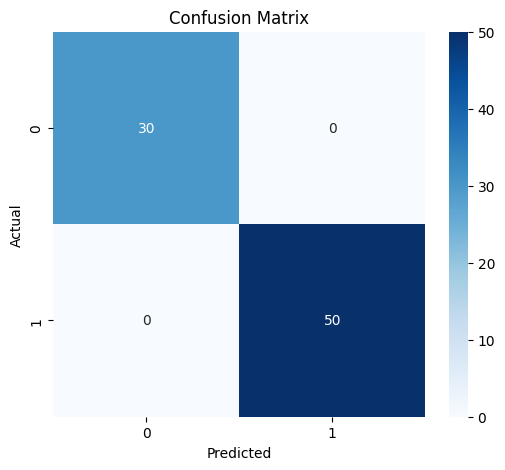

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix

cm = confusion_matrix(y_test, stack_pred)

# Plot

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
import joblib

# Save stacking model

joblib.dump(
    stack_model,
    'stack_model.pkl'
)

# Save scaler

joblib.dump(
    scaler,
    'scaler.pkl'
)

# Save selected features

joblib.dump(
    list(selected_features),
    'selected_features.pkl'
)

print("Everything saved successfully.")

Everything saved successfully.


# **Updated for FastAPI API Endpoint**

In [30]:
# Convert arrays back to dataframe

X_train_smote_df = pd.DataFrame(
    X_train_smote,
    columns=X.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

# Keep only RFE-selected features

X_train_final = X_train_smote_df[selected_features]

X_test_final = X_test_scaled_df[selected_features]

print(X_train_final.shape)
print(X_test_final.shape)

(400, 10)
(80, 10)


In [31]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()

X_train_final_scaled = final_scaler.fit_transform(
    X_train_final
)

X_test_final_scaled = final_scaler.transform(
    X_test_final
)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_final_scaled,
    y_train_smote
)

lr_pred = lr_model.predict(
    X_test_final_scaled
)

print(classification_report(
    y_test,
    lr_pred
))

print(
    "F1:",
    f1_score(y_test,lr_pred)
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

F1: 0.98989898989899


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_final_scaled,
    y_train_smote
)

rf_pred = rf_model.predict(
    X_test_final_scaled
)

print(classification_report(
    y_test,
    rf_pred
))

print(
    "F1:",
    f1_score(y_test,rf_pred)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

F1: 1.0


In [34]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_final_scaled,
    y_train_smote
)

xgb_pred = xgb_model.predict(
    X_test_final_scaled
)

print(classification_report(
    y_test,
    xgb_pred
))

print(
    "F1:",
    f1_score(y_test,xgb_pred)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

F1: 1.0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:07:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [35]:
from sklearn.ensemble import StackingClassifier

estimators = [

    (
        'lr',
        LogisticRegression(max_iter=1000)
    ),

    (
        'rf',
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    ),

    (
        'xgb',
        XGBClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )
    )

]

stack_model = StackingClassifier(

    estimators=estimators,

    final_estimator=
    LogisticRegression(),

    cv=5

)

stack_model.fit(
    X_train_final_scaled,
    y_train_smote
)

stack_pred = stack_model.predict(
    X_test_final_scaled
)

print(classification_report(
    y_test,
    stack_pred
))

print(
    "F1:",
    f1_score(y_test,stack_pred)
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:07:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:07:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

F1: 1.0


In [36]:
import joblib

joblib.dump(
    stack_model,
    "stack_model.pkl"
)

joblib.dump(
    final_scaler,
    "scaler.pkl"
)

joblib.dump(
    list(selected_features),
    "selected_features.pkl"
)

print("Saved successfully")

Saved successfully
